# Lab 5: Warping and Image Segmentation

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import math

imagesDir = './images'

## 1. Warping

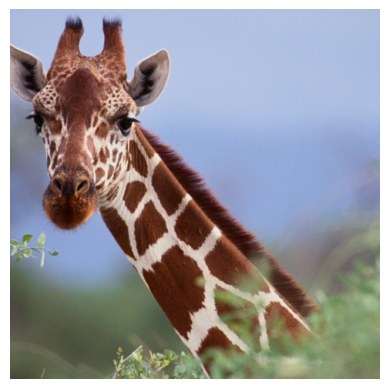

In [2]:
# Read image
img = cv2.imread(os.path.join(imagesDir, 'giraffe.jpg')) # Change this, according to your image's path

# Resize image to facilitate visualization
img = cv2.resize(img, (0, 0), fx = 0.4, fy = 0.4)

# Show image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
_ = plt.axis("off")

Affine Transformation

[[ 8.520e-01  1.500e-01  0.000e+00]
 [-8.000e-02  3.710e-01  1.584e+02]]


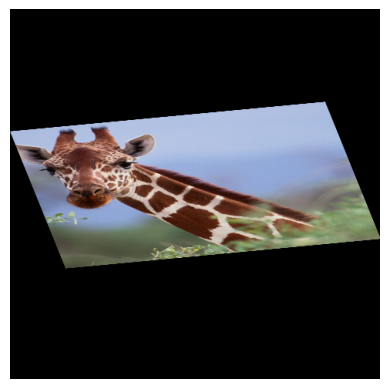

In [3]:
# Select original coordinates of three points of the original image
ori_coord = np.array([[0, 0], [img.shape[1] - 1, 0], [0, img.shape[0] - 1]]).astype(np.float32)

# Select target coordinates (where the points will move to)
tar_coord = np.array([[0, img.shape[0]*0.33], [img.shape[1]*0.85, img.shape[0]*0.25], [img.shape[1]*0.15, img.shape[0]*0.7]]).astype(np.float32)

# Get affine transformation matrix
warp_mat = cv2.getAffineTransform(ori_coord, tar_coord)
print(np.round(warp_mat, 3))

# Apply transformation to the image
warp_dst = cv2.warpAffine(img, warp_mat, (img.shape[1], img.shape[0]))

# Show Image
plt.imshow(cv2.cvtColor(warp_dst, cv2.COLOR_BGR2RGB))
_ = plt.axis("off")

Exercise 1.1: Rotate an image by [defining the rotation matrix](https://docs.opencv.org/4.x/da/d54/group__imgproc__transform.html#gafbbc470ce83812914a70abfb604f4326) and then applying transformation to the image.

Rotation Matrix:
 [[  0.707   0.707 -99.411]
 [ -0.707   0.707 240.   ]]


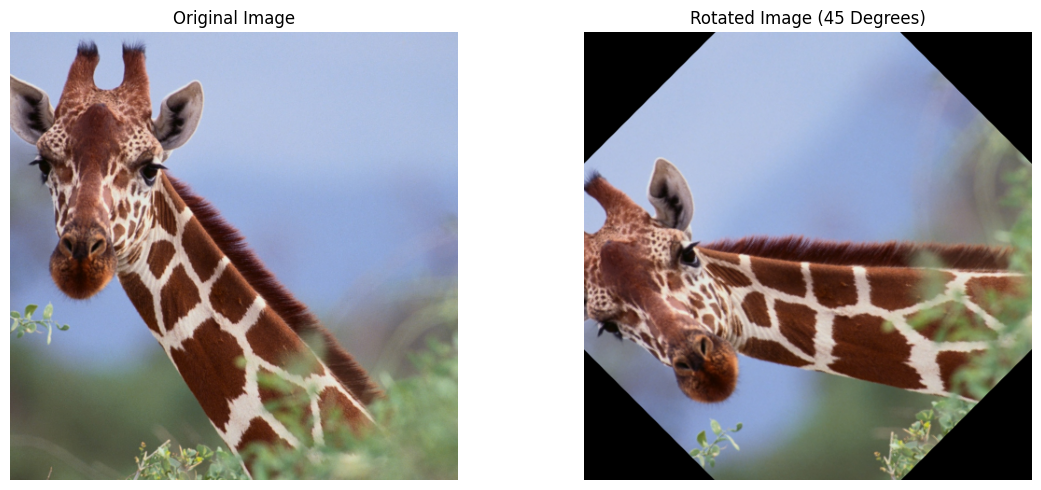

In [4]:
# shape[0] is height, shape[1] is width
height, width = img.shape[:2]
center = (width / 2, height / 2)

angle = 45  # Angle in degrees (positive values mean counter-clockwise rotation)
scale = 1.0

rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)

print("Rotation Matrix:\n", np.round(rotation_matrix, 3))

rotated_img = cv2.warpAffine(img, rotation_matrix, (width, height))

f, axarr = plt.subplots(1, 2, figsize=(12, 5))

axarr[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr[0].set_title("Original Image")
axarr[0].axis("off")

axarr[1].imshow(cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB))
axarr[1].set_title(f"Rotated Image ({angle} Degrees)")
axarr[1].axis("off")

plt.tight_layout()
plt.show()

Exercise 1.2: Rotate an image through cv2.getAffineTransform().

Manual Rotation Matrix:
 [[  0.707   0.707 -99.411]
 [ -0.707   0.707 240.   ]]


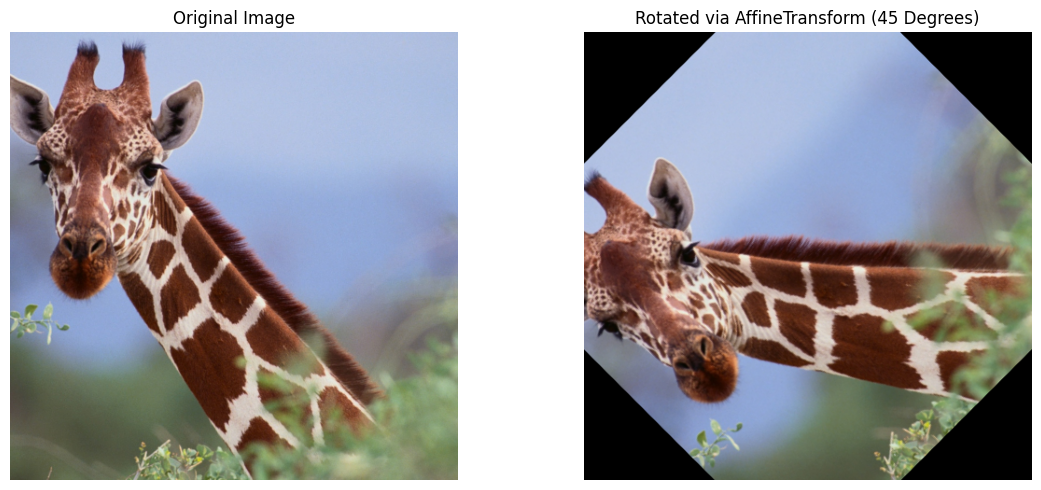

In [5]:
height, width = img.shape[:2]
cx, cy = width / 2, height / 2

angle_deg = 45
angle_rad = math.radians(angle_deg)

cos_a = math.cos(angle_rad)
sin_a = math.sin(angle_rad)

# Choose 3 points in the original image
#  Use a distance 'd' of 100 pixels to create our reference points
d = 100

pt1_src = [cx, cy]           # Center point
pt2_src = [cx + d, cy]       # 100 pixels to the right
pt3_src = [cx, cy - d]       # 100 pixels up (in OpenCV, Y goes down, so we subtract)

src_pts = np.float32([pt1_src, pt2_src, pt3_src])

pt1_dst = [cx, cy]
pt2_dst = [cx + d * cos_a, cy - d * sin_a]
pt3_dst = [cx - d * sin_a, cy - d * cos_a]

dst_pts = np.float32([pt1_dst, pt2_dst, pt3_dst])

warp_mat = cv2.getAffineTransform(src_pts, dst_pts)

print("Manual Rotation Matrix:\n", np.round(warp_mat, 3))

rotated_img_affine = cv2.warpAffine(img, warp_mat, (width, height))

f, axarr = plt.subplots(1, 2, figsize=(12, 5))

axarr[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr[0].set_title("Original Image")
axarr[0].axis("off")

axarr[1].imshow(cv2.cvtColor(rotated_img_affine, cv2.COLOR_BGR2RGB))
axarr[1].set_title(f"Rotated via AffineTransform ({angle_deg} Degrees)")
axarr[1].axis("off")

plt.tight_layout()
plt.show()

Exercise 1.3: Implement transformation matrices (without using getAffineTransform or getRotationMatrix2D) to achieve the following goals:
* Apply a translation of 100 pixels to the right
* Apply a rotation of 90 degrees 
* Scale the image to twice its size

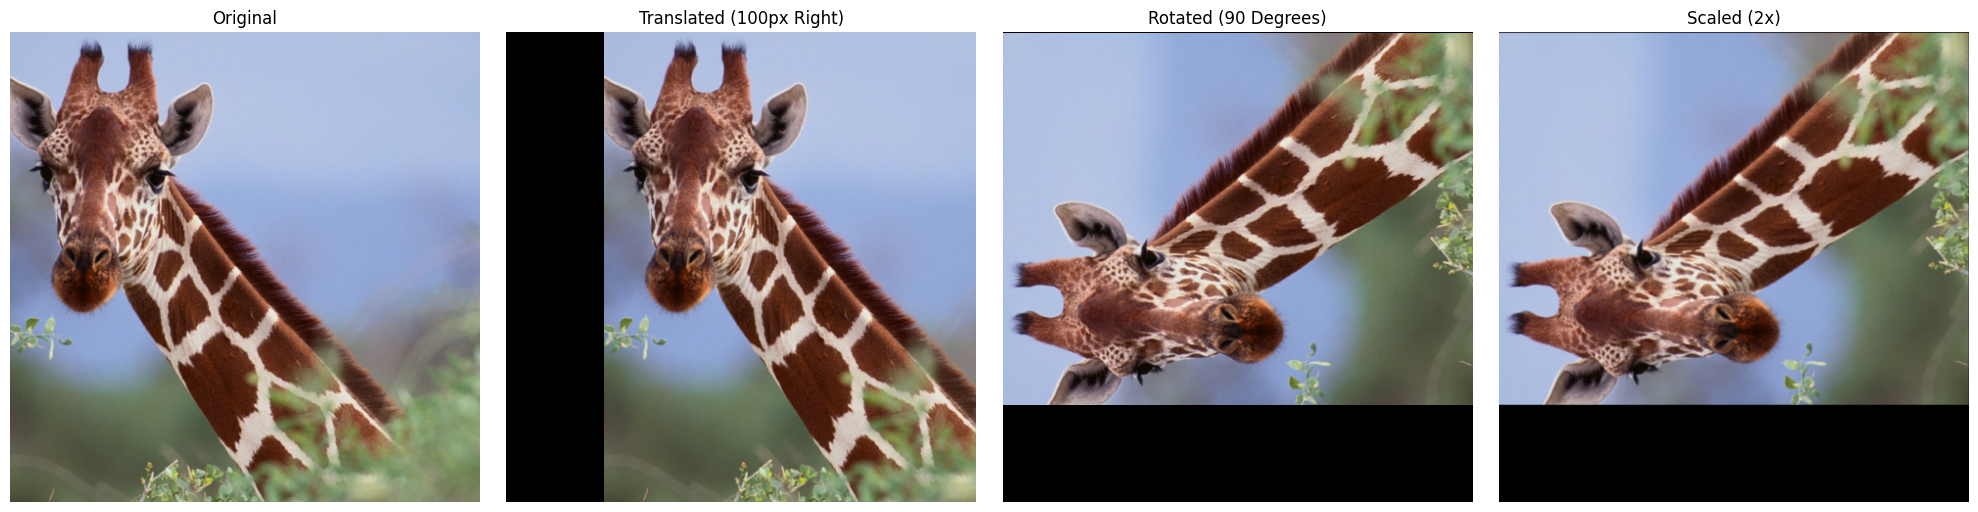

In [6]:
h, w = img.shape[:2]

# Translation (100 pixels right)
# [1, 0, tx]
# [0, 1, ty]
M_trans = np.float32([
    [1, 0, 100],
    [0, 1, 0]
])
img_trans = cv2.warpAffine(img, M_trans, (w, h))

angle_rad = math.radians(90)
cos_a = math.cos(angle_rad)
sin_a = math.sin(angle_rad)
cx, cy = w / 2, h / 2

# Building the rotation matrix centered at (cx, cy)
M_rot = np.float32([
    [cos_a,  sin_a, (1 - cos_a) * cx - sin_a * cy],
    [-sin_a, cos_a, sin_a * cx + (1 - cos_a) * cy]
])
img_rot = cv2.warpAffine(img_trans, M_rot, (w, h))

# Scaling (Twice its size)
# [sx, 0, 0]
# [0, sy, 0]
M_scale = np.float32([
    [2, 0, 0],
    [0, 2, 0]
])
img_scale = cv2.warpAffine(img_rot, M_scale, (w * 2, h * 2))

f, axarr = plt.subplots(1, 4, figsize=(20, 5))

axarr[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr[0].set_title("Original")
axarr[0].axis("off")

axarr[1].imshow(cv2.cvtColor(img_trans, cv2.COLOR_BGR2RGB))
axarr[1].set_title("Translated (100px Right)")
axarr[1].axis("off")

axarr[2].imshow(cv2.cvtColor(img_rot, cv2.COLOR_BGR2RGB))
axarr[2].set_title("Rotated (90 Degrees)")
axarr[2].axis("off")

axarr[3].imshow(cv2.cvtColor(img_scale, cv2.COLOR_BGR2RGB))
axarr[3].set_title("Scaled (2x)")
axarr[3].axis("off")

plt.tight_layout()
plt.show()

### Homography

Example of homography using feature matching from last week

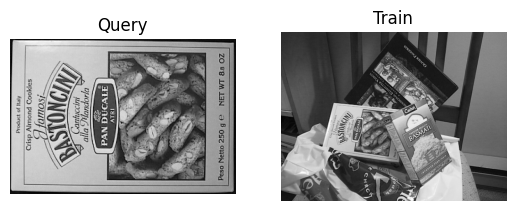

In [7]:
# Load images
img1 = cv2.imread(os.path.join(imagesDir, 'match_box01a_1.png'), cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(os.path.join(imagesDir, 'match_box01a_2.png'), cv2.IMREAD_GRAYSCALE)

plt.subplot(1, 2, 1)
plt.title('Query'); plt.imshow(img1, cmap='gray'); plt.axis("off")
plt.subplot(1, 2, 2)
plt.title('Train'); plt.imshow(img2, cmap='gray'); plt.axis("off")
plt.show()

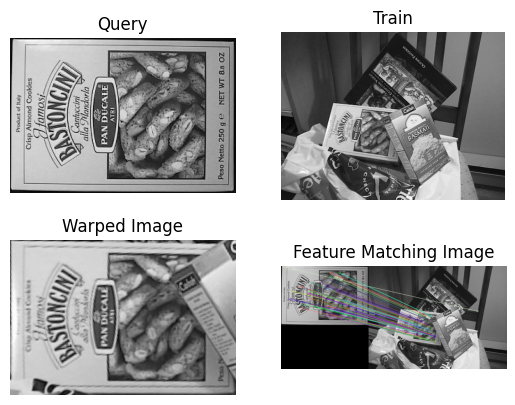

In [8]:
# Initiate SIFT detector
sift = cv2.SIFT_create()

# Find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# Apply FLANN Matcher
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks = 50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1,des2,k=2)

# Store all the good matches as per Lowe's ratio test
good = []
for m, n in matches:
    if m.distance/n.distance < 0.7:
        good.append(m)

match_output = cv2.drawMatchesKnn(img1, kp1, img2, kp2, np.expand_dims(good, 0), None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Obtain points corresponding to the matches in the query and train images
query_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
train_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

# Obtain homography that represents the transformation from the points of the train image into the position of the query image
M, mask = cv2.findHomography(train_pts, query_pts, cv2.RANSAC, 5.0)

# Apply transformation to image
warped_img = cv2.warpPerspective(img2, M, (img1.shape[1], img1.shape[0]),flags=cv2.INTER_LINEAR)

plt.subplot(2, 2, 1)
plt.title('Query'); plt.imshow(img1, cmap='gray'); plt.axis("off")
plt.subplot(2, 2, 2)
plt.title('Train'); plt.imshow(img2, cmap='gray'); plt.axis("off")
plt.subplot(2, 2, 3)
plt.title('Warped Image'); plt.imshow(warped_img, cmap='gray'); plt.axis("off")
plt.subplot(2, 2, 4)
plt.title('Feature Matching Image'); plt.imshow(match_output, cmap='gray'); plt.axis("off")
plt.show()

Exercise 1.4: Apply the drawMatches() function (check last week's notebook) to visualize the feature matching after removing the outliers using RANSAC. Compare the results of removing outliers using RANSAC with the Lowe's ratio test implemented last week.

Hint: The output mask from cv2.findHomography() represents the inliers.

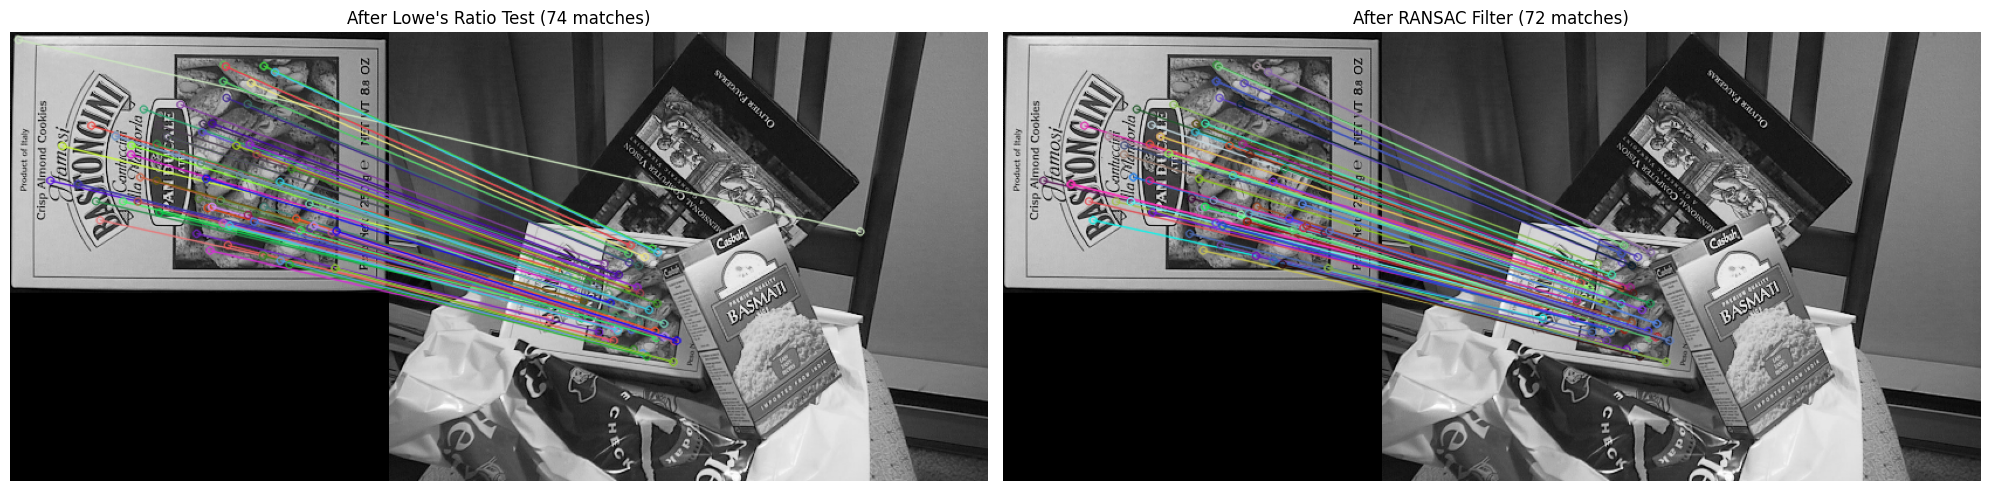

Matches after Lowe's Test: 74
Matches after RANSAC: 72
RANSAC removed 2 outliers that Lowe's test missed!


In [9]:
mask_list = mask.ravel().tolist() # # 1 means INLIER (RANSAC approved), 0 means OUTLIER (RANSAC rejected)

ransac_inliers = []
for i, match in enumerate(good):
    if mask_list[i] == 1:
        ransac_inliers.append(match)

match_output_ransac = cv2.drawMatches(
    img1, kp1, 
    img2, kp2, 
    ransac_inliers, 
    None, 
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

f, axarr = plt.subplots(1, 2, figsize=(20, 6))

axarr[0].imshow(match_output, cmap='gray') # match_output was generated in the previous cell
axarr[0].set_title(f"After Lowe's Ratio Test ({len(good)} matches)")
axarr[0].axis("off")

axarr[1].imshow(match_output_ransac, cmap='gray')
axarr[1].set_title(f"After RANSAC Filter ({len(ransac_inliers)} matches)")
axarr[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Matches after Lowe's Test: {len(good)}")
print(f"Matches after RANSAC: {len(ransac_inliers)}")
print(f"RANSAC removed {len(good) - len(ransac_inliers)} outliers that Lowe's test missed!")

Exercise 1.5: Draw lines around the object by:
* Obtaining homography that transforms points from the query image to the train image
* Applying [the perspectiveTransform function](https://docs.opencv.org/3.4/d2/de8/group__core__array.html#gad327659ac03e5fd6894b90025e6900a7) to obtain the coordinates of the object of the query image on the train image
* Drawing lines on the train image that connect the coordinates of the object using [polylines](https://docs.opencv.org/3.4/d6/d6e/group__imgproc__draw.html#gaa3c25f9fb764b6bef791bf034f6e26f5)

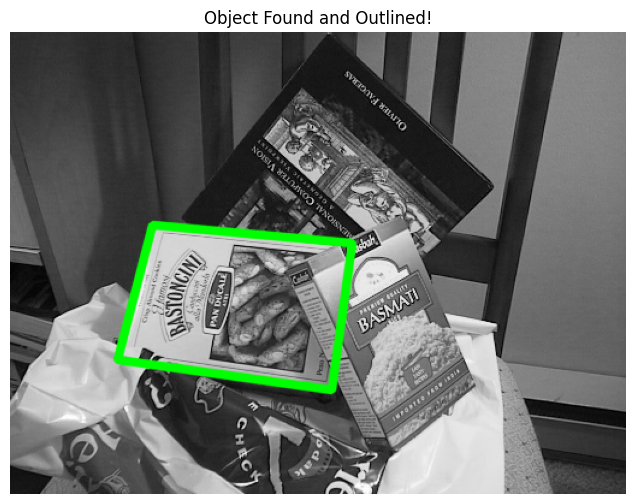

In [10]:
M_box, mask_box = cv2.findHomography(query_pts, train_pts, cv2.RANSAC, 5.0) # Obtaining homography (Query -> Train)

if M_box is not None:
    h, w = img1.shape

    pts = np.float32([ [0, 0], [0, h-1], [w-1, h-1], [w-1, 0] ]).reshape(-1, 1, 2)

    dst = cv2.perspectiveTransform(pts, M_box)

    img2_result = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)

    img2_result = cv2.polylines(img2_result, [np.int32(dst)], True, (0, 255, 0), 5, cv2.LINE_AA)

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(img2_result, cv2.COLOR_BGR2RGB))
    plt.title("Object Found and Outlined!")
    plt.axis("off")
    plt.show()

else:
    print("Error: Could not calculate Homography.")

# 2. Segmentation

### Thresholding

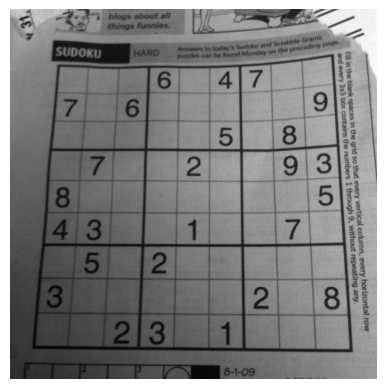

In [11]:
# Read image
img = cv2.imread(os.path.join(imagesDir, 'sudoku.png'))

# Convert to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Show image
plt.imshow(img, cmap='gray')
plt.axis("off");

Otsu Thresholding

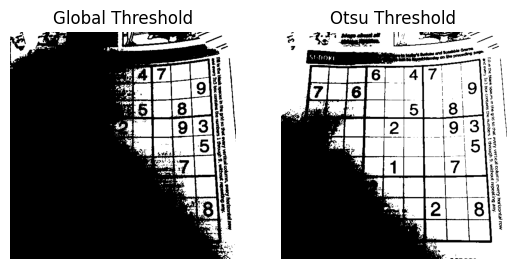

In [12]:
# Apply global binary threshold
ret, th_global = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Apply binary threshold with Otsu's method
ret, th_otsu = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Show images
plt.subplot(1, 2, 1)
plt.title('Global Threshold'); plt.imshow(th_global, cmap='gray'); plt.axis("off")
plt.subplot(1, 2, 2)
plt.title('Otsu Threshold'); plt.imshow(th_otsu, cmap='gray'); plt.axis("off")
plt.show()

Exercise 2.1: Verify the effects of blurring the image using a Gaussian filter, before applying the Otsu thresholding method.

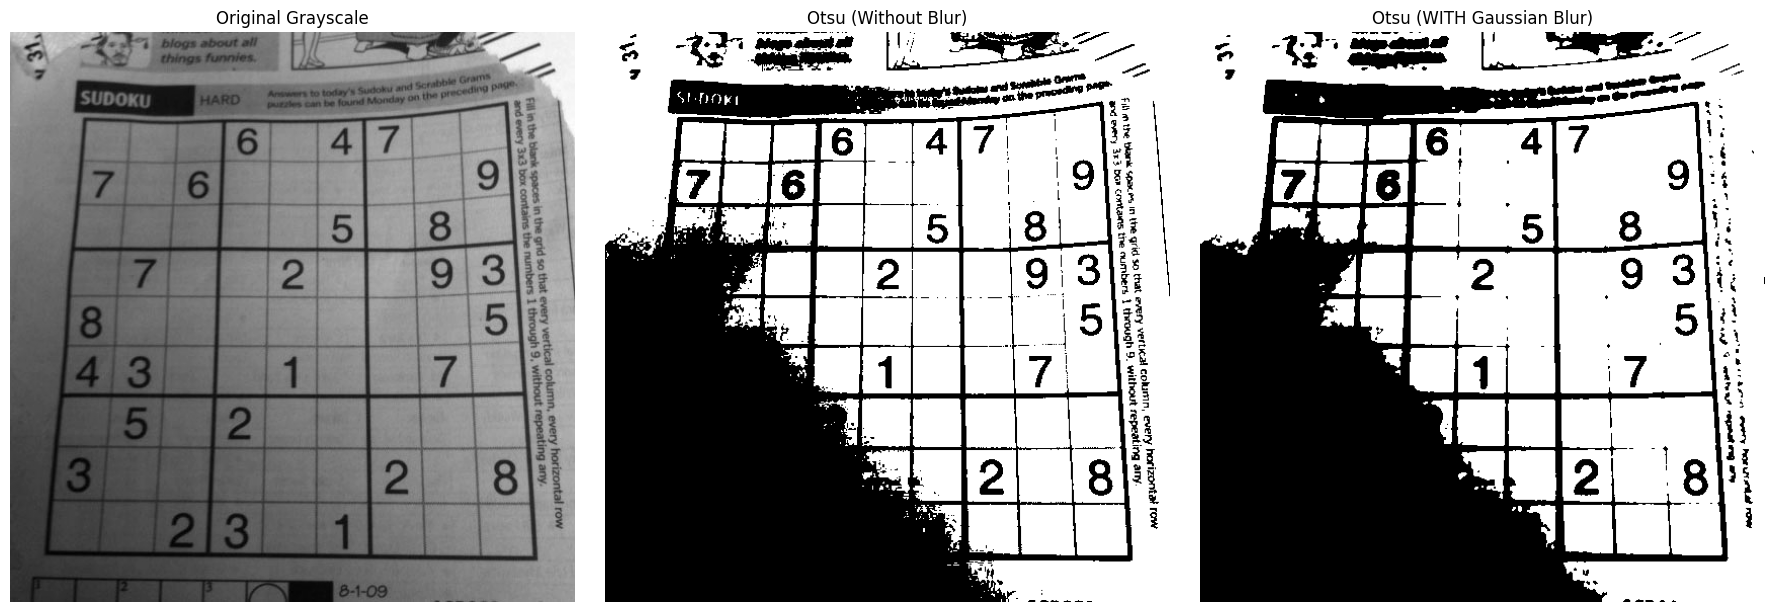

Otsu's chosen threshold without blur: 97.0
Otsu's chosen threshold WITH blur: 97.0


In [13]:
blur_img = cv2.GaussianBlur(img, (5, 5), 0)

ret_blur, th_otsu_blur = cv2.threshold(blur_img, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

f, axarr = plt.subplots(1, 3, figsize=(18, 6))

axarr[0].imshow(img, cmap='gray')
axarr[0].set_title("Original Grayscale")
axarr[0].axis("off")

axarr[1].imshow(th_otsu, cmap='gray')
axarr[1].set_title("Otsu (Without Blur)")
axarr[1].axis("off")

axarr[2].imshow(th_otsu_blur, cmap='gray')
axarr[2].set_title("Otsu (WITH Gaussian Blur)")
axarr[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Otsu's chosen threshold without blur: {ret}")
print(f"Otsu's chosen threshold WITH blur: {ret_blur}")

Adaptive Threshold

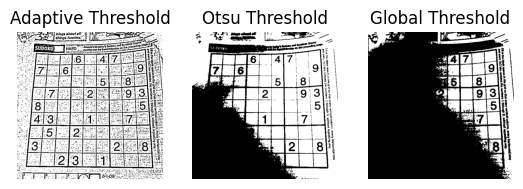

In [14]:
# Apply adaptive thresholding
th_adaptive = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

# Show images
plt.subplot(1, 3, 1)
plt.title('Adaptive Threshold'); plt.imshow(th_adaptive, cmap='gray'); plt.axis("off")
plt.subplot(1, 3, 2)
plt.title('Otsu Threshold'); plt.imshow(th_otsu, cmap='gray'); plt.axis("off")
plt.subplot(1, 3, 3)
plt.title('Global Threshold'); plt.imshow(th_global, cmap='gray'); plt.axis("off")
plt.show()

Exercise 2.2: Verify the effects of blurring with filters of increasing sizes before applying the adaptive threshold.

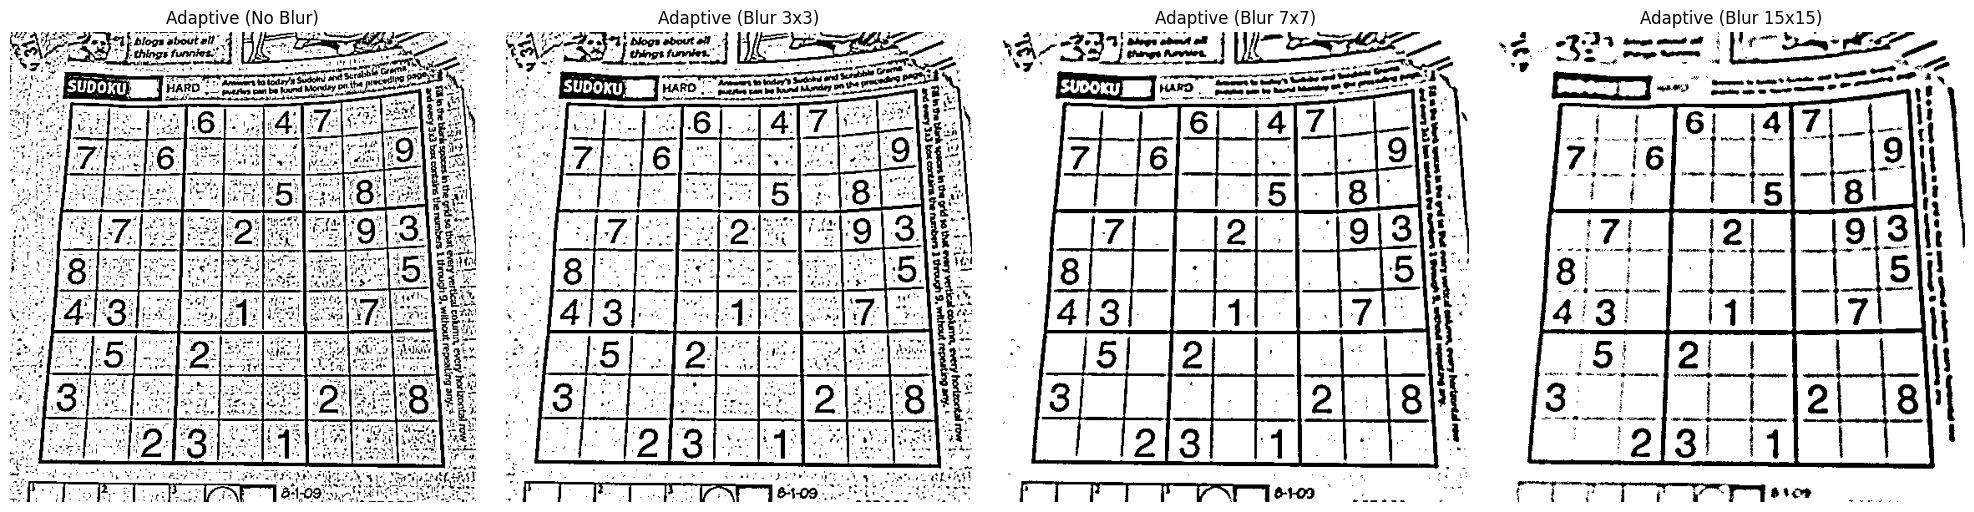

In [15]:
kernel_sizes = [(3, 3), (7, 7), (15, 15)]

f, axarr = plt.subplots(1, 4, figsize=(20, 5))

th_no_blur = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
axarr[0].imshow(th_no_blur, cmap='gray')
axarr[0].set_title('Adaptive (No Blur)')
axarr[0].axis('off')

for i, k in enumerate(kernel_sizes):
    # Apply Gaussian Blur with current kernel size
    blurred = cv2.GaussianBlur(img, k, 0)
    
    # Apply Adaptive Threshold to the blurred image
    th_adapt = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    
    # Plot the result
    axarr[i+1].imshow(th_adapt, cmap='gray')
    axarr[i+1].set_title(f'Adaptive (Blur {k[0]}x{k[1]})')
    axarr[i+1].axis('off')

plt.tight_layout()
plt.show()

### Segmentation with [K-Means](https://docs.opencv.org/master/d5/d38/group__core__cluster.html#ga9a34dc06c6ec9460e90860f15bcd2f88)

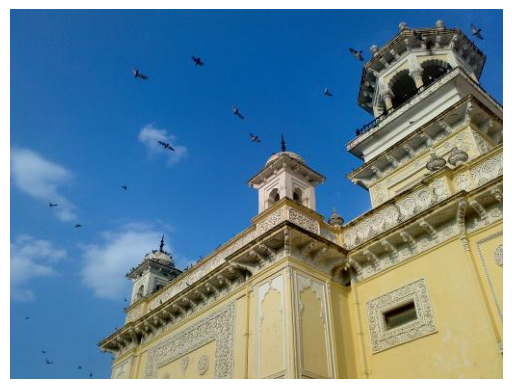

In [17]:
# Read image
img2 = cv2.imread(os.path.join(imagesDir, 'home.jpg'))

# Show image
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.axis("off");

In [18]:
# Reshape the image and turn its values to float
print(f"Previous shape: {img2.shape}")

reshaped_image = img2.reshape((-1,3))
reshaped_image = np.float32(reshaped_image)

print(f"Current shape: {reshaped_image.shape}")

# Define criteria and number of clusters (k)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
k = 4

# Apply K-means
ret, label, center = cv2.kmeans(reshaped_image, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

Previous shape: (384, 512, 3)
Current shape: (196608, 3)


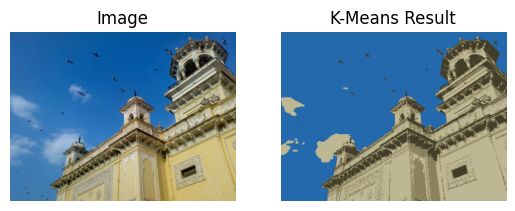

In [19]:
# Convert back to uint8, and make resulting image
center = np.uint8(center)
result = center[label.flatten()]
result = result.reshape((img2.shape))

# Show image
plt.subplot(1, 2, 1)
plt.title('Image'); plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.subplot(1, 2, 2)
plt.title('K-Means Result'); plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.show()

Exercise 2.3: Experiment with different number of clusters.

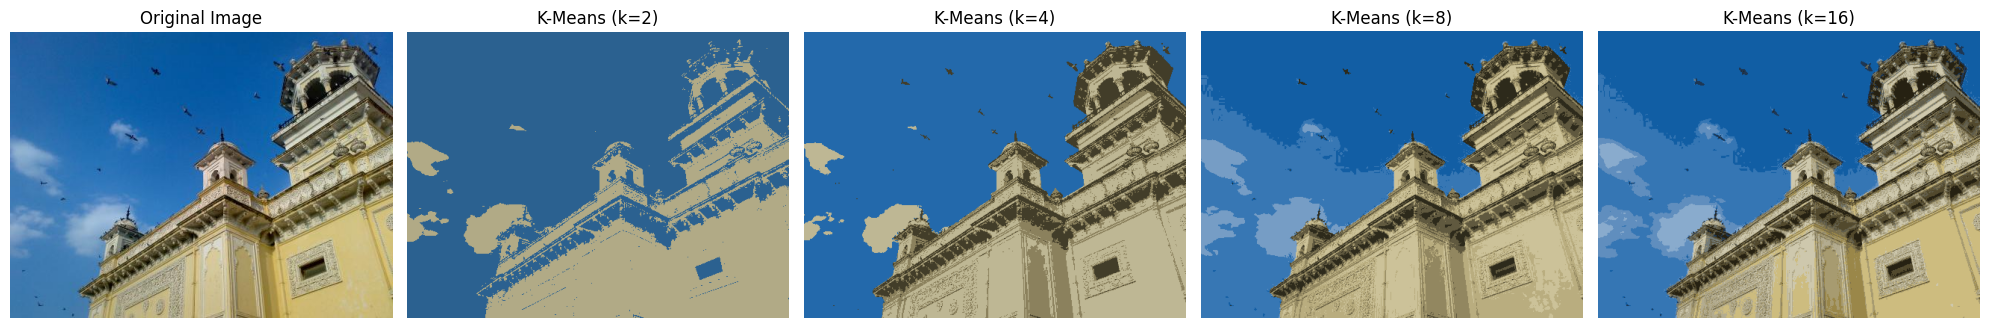

In [20]:
reshaped_image = img2.reshape((-1, 3))
reshaped_image = np.float32(reshaped_image)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

k_values = [2, 4, 8, 16]

f, axarr = plt.subplots(1, len(k_values) + 1, figsize=(20, 5))

axarr[0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axarr[0].set_title('Original Image')
axarr[0].axis('off')

for i, k in enumerate(k_values):
    ret, label, center = cv2.kmeans(reshaped_image, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    
    center = np.uint8(center)
    result = center[label.flatten()]
    result_img = result.reshape((img2.shape))
    
    axarr[i+1].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    axarr[i+1].set_title(f'K-Means (k={k})')
    axarr[i+1].axis('off')

plt.tight_layout()
plt.show()

### Segmentation with [GrabCut](https://docs.opencv.org/4.x/d3/d47/group__imgproc__segmentation.html#ga909c1dda50efcbeaa3ce126be862b37f)

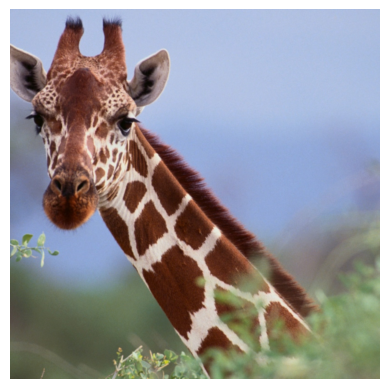

In [21]:
# Read image
img = cv2.imread(os.path.join(imagesDir, 'giraffe.jpg'))

# Resize image to facilitate visualization
img = cv2.resize(img, (0, 0), fx = 0.6, fy = 0.6)

# Show image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off");

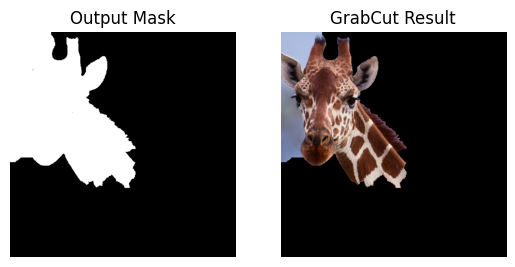

In [22]:
# Define image mask for the GrabCut output with same dimensions as the image
mask = np.zeros(img.shape[:2], np.uint8)

# Define the bounding box coordinates with the object of interest: (x, y, width, heigh)
bb = (0, 0, 400, 500)

# Allocate memory for the two arrays that this algorithm internally uses for the segmentation of the foreground and background
bgModel = np.zeros((1, 65), np.float64)
fgModel = np.zeros((1, 65), np.float64)

# Apply GrabCut
(mask, bgModel, fgModel) = cv2.grabCut(img, mask, bb, bgModel, fgModel, 5, cv2.GC_INIT_WITH_RECT)

# All definite background and probable background pixels are set to 0, and all definite foreground and probable foreground pixels are set to 1
output_mask = np.where((mask == cv2.GC_BGD) | (mask == cv2.GC_PR_BGD), 0, 1)

# Scale the mask from the range [0, 1] to [0, 255]
output_mask = (output_mask * 255).astype("uint8")

# Apply a bitwise AND to the image using the generated mask by GrabCut to obtain the final result
grabcut_result = cv2.bitwise_and(img, img, mask=output_mask)

# Show result
plt.subplot(1, 2, 1)
plt.title('Output Mask'); plt.imshow(output_mask, cmap='gray'); plt.axis("off")
plt.subplot(1, 2, 2)
plt.title('GrabCut Result'); plt.imshow(cv2.cvtColor(grabcut_result, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.show()

Exercise 2.4: Select a region of interest in the image (using cv2.selectROI function) for the GrabCut algorithm.

Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!


QFontDatabase: Cannot find font directory /home/rui/Documentos/Faculdade/VC/myenv/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/rui/Documentos/Faculdade/VC/myenv/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/rui/Documentos/Faculdade/VC/myenv/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/rui/Documentos/Faculdade/VC/myenv/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFon

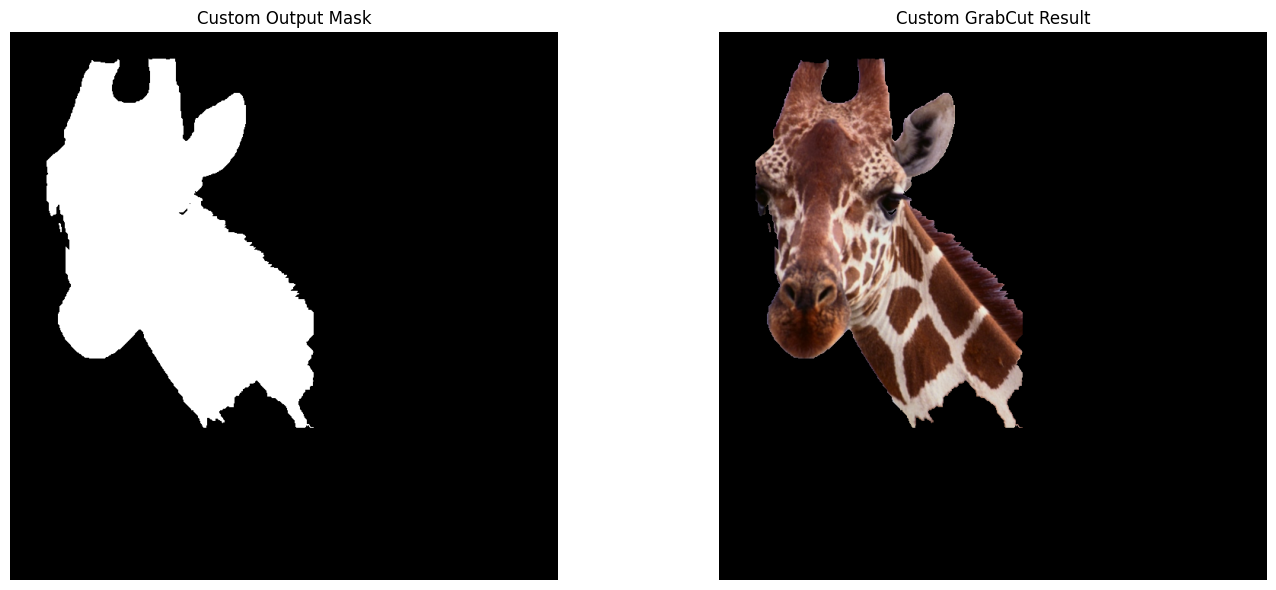

In [23]:
bb = cv2.selectROI("Select ROI (Press SPACE to confirm)", img, showCrosshair=True, fromCenter=False)

cv2.destroyWindow("Select ROI (Press SPACE to confirm)")

if bb[2] > 0 and bb[3] > 0:
    mask = np.zeros(img.shape[:2], np.uint8)
    
    bgModel = np.zeros((1, 65), np.float64)
    fgModel = np.zeros((1, 65), np.float64)

    cv2.grabCut(img, mask, bb, bgModel, fgModel, 5, cv2.GC_INIT_WITH_RECT)

    output_mask = np.where((mask == cv2.GC_BGD) | (mask == cv2.GC_PR_BGD), 0, 1).astype("uint8")

    output_mask_visual = output_mask * 255

    grabcut_result = cv2.bitwise_and(img, img, mask=output_mask)

    f, axarr = plt.subplots(1, 2, figsize=(15, 6))
    
    axarr[0].imshow(output_mask_visual, cmap='gray')
    axarr[0].set_title('Custom Output Mask')
    axarr[0].axis("off")
    
    axarr[1].imshow(cv2.cvtColor(grabcut_result, cv2.COLOR_BGR2RGB))
    axarr[1].set_title('Custom GrabCut Result')
    axarr[1].axis("off")
    
    plt.tight_layout()
    plt.show()

else:
    print("You didn't draw a valid box. Run the cell again!")